In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, precision_score, recall_score)
from sklearn.preprocessing import LabelEncoder


import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.stem import WordNetLemmatizer

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [2]:
!pip install transformers datasets accelerate -q

In [4]:
import pandas as pd
import numpy as np
import torch
from transformers import (DistilBertTokenizer, DistilBertForSequenceClassification,
                          Trainer, TrainingArguments)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset
import re

## 1. ЗАГРУЗКА И ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ 

In [5]:
df_train = pd.read_csv('/kaggle/input/datasets/jp797498e/twitter-entity-sentiment-analysis/twitter_training.csv',
                        header=None,
                        names=['Tweet_ID', 'Topic', 'Sentiment', 'Tweet'])

df_val = pd.read_csv('/kaggle/input/datasets/jp797498e/twitter-entity-sentiment-analysis/twitter_validation.csv',
                      header=None,
                      names=['Tweet_ID', 'Topic', 'Sentiment', 'Tweet'])

print(f"Размер обучающей выборки: {df_train.shape}")
print(f"Размер валидационной выборки: {df_val.shape}")

df = pd.concat([df_train, df_val], ignore_index=True)
print(f"Общий размер после объединения: {df.shape}")

Размер обучающей выборки: (74682, 4)
Размер валидационной выборки: (1000, 4)
Общий размер после объединения: (75682, 4)


### 1.1 Общая информация о данных

In [6]:
print("Типы данных")
print(df.dtypes)

print("Первые 5 строк")
print(df.head())

print("Пропуски")
print(df.isnull().sum())
print(f"Доля пропусков в Tweet: {df['Tweet'].isnull().mean():.2%}")

print("Дубликаты")
full_dupes = df.duplicated().sum()
text_dupes = df['Tweet'].duplicated().sum()
print(f"Полных дубликатов: {full_dupes} ({full_dupes/len(df):.1%})")
print(f"Дубликатов по тексту: {text_dupes} ({text_dupes/len(df):.1%})")

Типы данных
Tweet_ID      int64
Topic        object
Sentiment    object
Tweet        object
dtype: object
Первые 5 строк
   Tweet_ID        Topic Sentiment  \
0      2401  Borderlands  Positive   
1      2401  Borderlands  Positive   
2      2401  Borderlands  Positive   
3      2401  Borderlands  Positive   
4      2401  Borderlands  Positive   

                                               Tweet  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  
Пропуски
Tweet_ID       0
Topic          0
Sentiment      0
Tweet        686
dtype: int64
Доля пропусков в Tweet: 0.91%
Дубликаты
Полных дубликатов: 3217 (4.3%)
Дубликатов по тексту: 5707 (7.5%)


### 1.2 Распределение целевой переменной (Sentiment)

 Распределение Sentiment
Sentiment
Negative      22808
Positive      21109
Neutral       18603
Irrelevant    13162
Name: count, dtype: int64


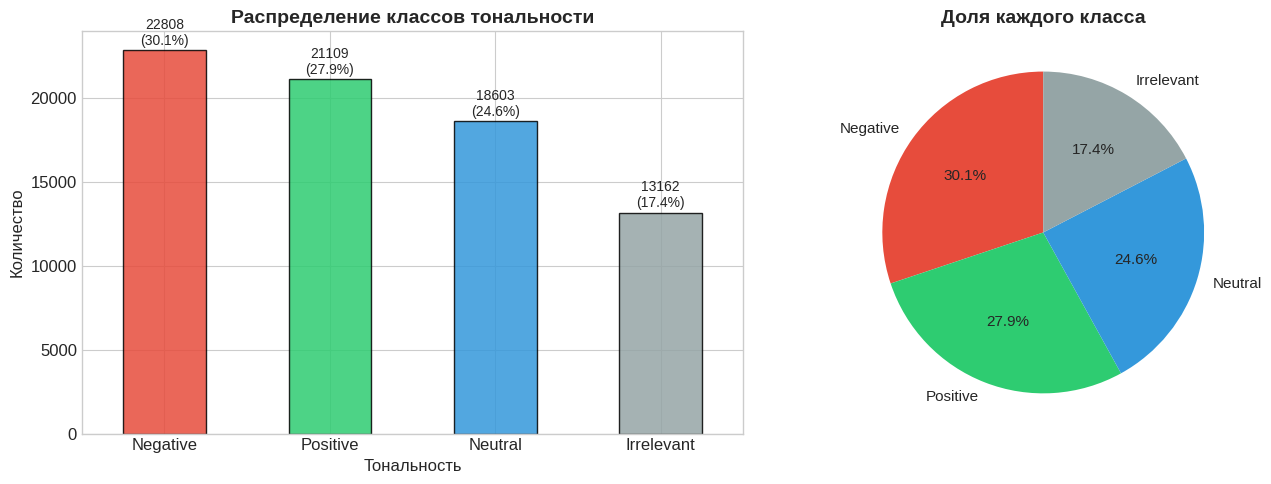

Сохранено: 01_sentiment_distribution.png


In [7]:
print(" Распределение Sentiment")
print(df['Sentiment'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sentiment_counts = df['Sentiment'].value_counts()
colors = ['#e74c3c', '#2ecc71', '#3498db', '#95a5a6']
sentiment_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Распределение классов тональности', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Тональность')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 300, f'{v}\n({v/len(df):.1%})', ha='center', fontsize=10)

axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index,
            colors=colors, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('Доля каждого класса', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('01_sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 01_sentiment_distribution.png")

### 1.3 Распределение по брендам (Topic)

Бренды (32 уникальных)
Topic
TomClancysRainbowSix                 2435
LeagueOfLegends                      2431
MaddenNFL                            2429
Microsoft                            2428
CallOfDuty                           2425
Verizon                              2414
ApexLegends                          2412
CallOfDutyBlackopsColdWar            2403
Facebook                             2403
WorldOfCraft                         2394
Dota2                                2391
FIFA                                 2378
NBA2K                                2373
Battlefield                          2372
TomClancysGhostRecon                 2368
johnson&johnson                      2367
Overwatch                            2366
Xbox(Xseries)                        2360
Amazon                               2350
PlayStation5(PS5)                    2343
GrandTheftAuto(GTA)                  2339
CS-GO                                2336
Cyberpunk2077                        2334
Nvidi

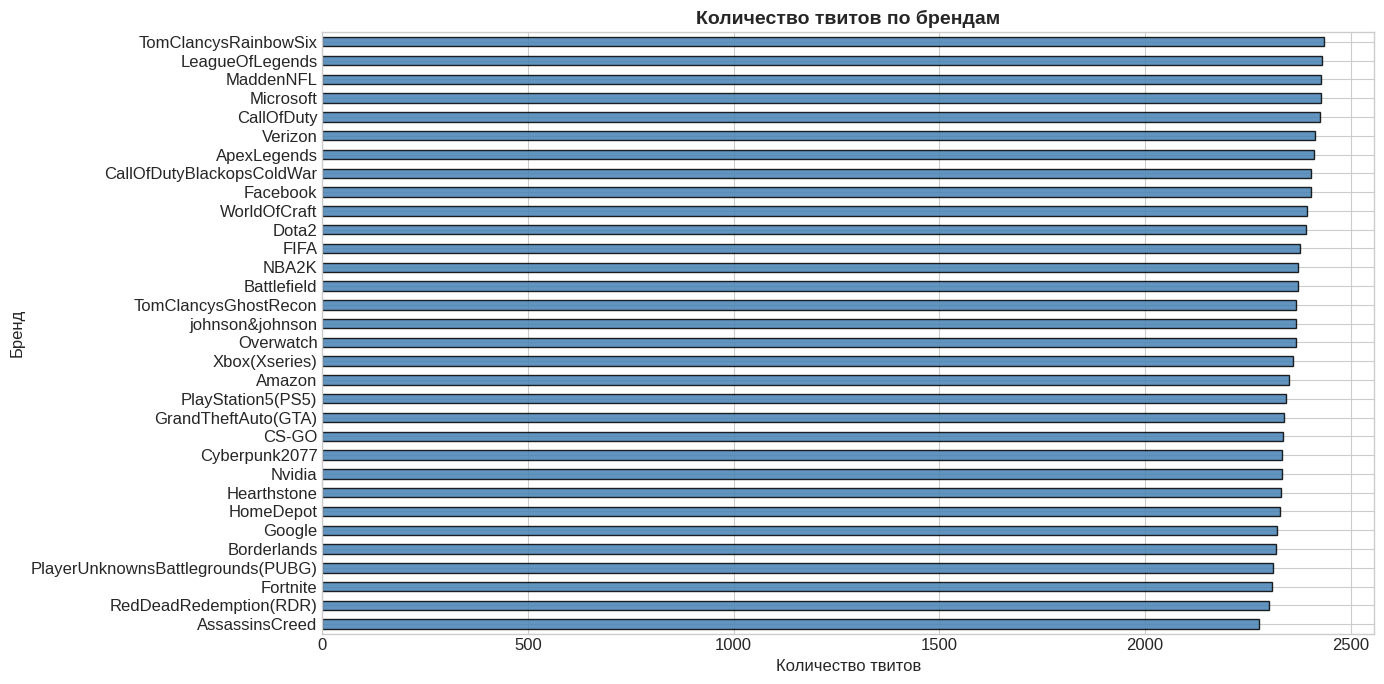

Сохранено: 02_topics_distribution.png


In [8]:
print(f"Бренды ({df['Topic'].nunique()} уникальных)")
topic_counts = df['Topic'].value_counts()
print(topic_counts)

fig, ax = plt.subplots(figsize=(14, 7))
topic_counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black', alpha=0.85)
ax.set_title('Количество твитов по брендам', fontsize=14, fontweight='bold')
ax.set_xlabel('Количество твитов')
ax.set_ylabel('Бренд')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('02_topics_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 02_topics_distribution.png")

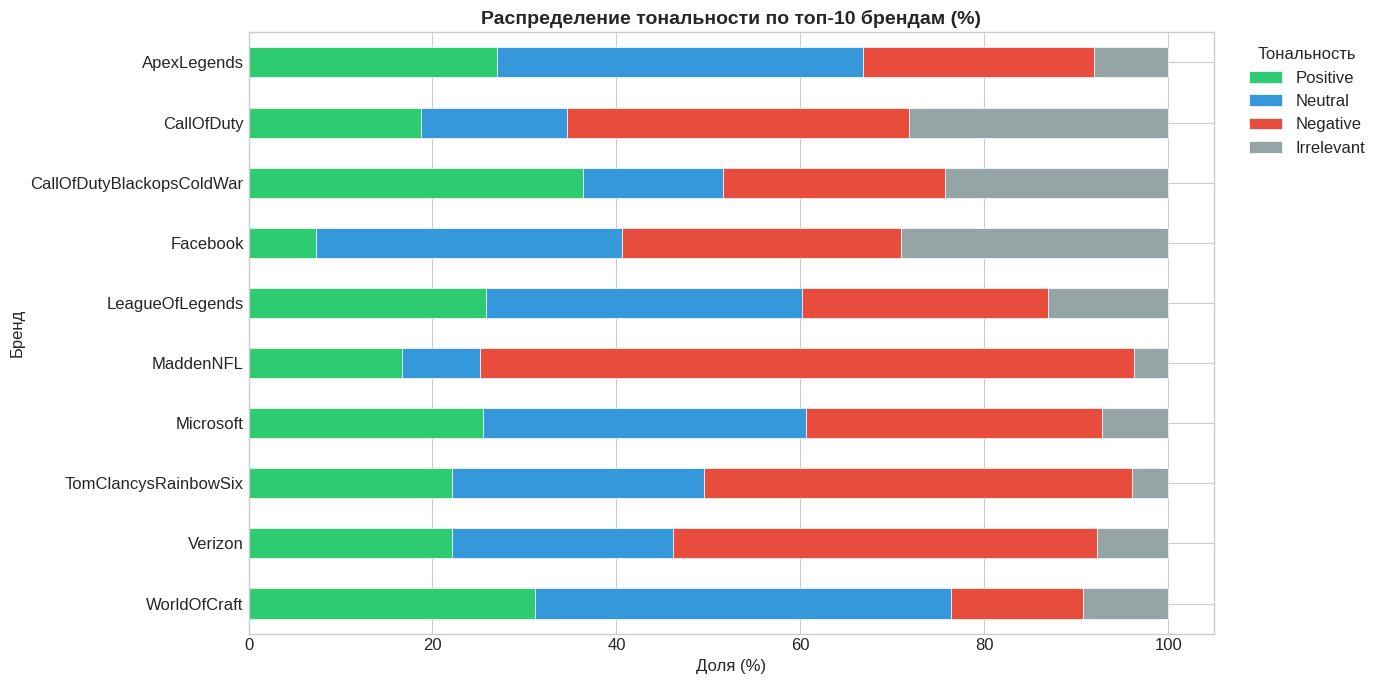

Сохранено: 03_sentiment_by_topic.png


In [9]:
top10_topics = df['Topic'].value_counts().head(10).index
df_top10 = df[df['Topic'].isin(top10_topics)]

ct = pd.crosstab(df_top10['Topic'], df_top10['Sentiment'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(14, 7))
ct[['Positive', 'Neutral', 'Negative', 'Irrelevant']].plot(
    kind='barh', stacked=True, ax=ax,
    color=['#2ecc71', '#3498db', '#e74c3c', '#95a5a6'],
    edgecolor='white', linewidth=0.5)
ax.set_title('Распределение тональности по топ-10 брендам (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Доля (%)')
ax.set_ylabel('Бренд')
ax.legend(title='Тональность', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('03_sentiment_by_topic.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 03_sentiment_by_topic.png")

## ЭТАП 2: ОЧИСТКА И ПРЕДОБРАБОТКА ТЕКСТА

### 2.1 Удаление пропусков и дубликатов

In [10]:
print(f"Размер до очистки: {len(df)}")

df = df.dropna(subset=['Tweet'])
print(f"После удаления NaN: {len(df)}")

df = df.drop_duplicates()
print(f"После удаления полных дубликатов: {len(df)}")

df = df[df['Tweet'].str.len() > 5]
print(f"После удаления коротких текстов (<=5 симв.): {len(df)}")

df = df.drop_duplicates(subset=['Tweet'], keep='first')
print(f"После удаления дубликатов по тексту: {len(df)}")

df = df.reset_index(drop=True)

Размер до очистки: 75682
После удаления NaN: 74996
После удаления полных дубликатов: 72139
После удаления коротких текстов (<=5 симв.): 70328
После удаления дубликатов по тексту: 69670


### 2.2 Функция очистки текста

In [11]:
stop_words = set(ENGLISH_STOP_WORDS)
lemmatizer = WordNetLemmatizer()
def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    #  URL
    text = re.sub(r'http\S+|www\.\S+', '', text)
    #  @упоминания
    text = re.sub(r'@\w+', '', text)
    # символ #, слово оставляем
    text = re.sub(r'#', '', text)
    # числа
    text = re.sub(r'\d+', '', text)
    # пунктуация и спецсимволы
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # лишние пробелы
    text = re.sub(r'\s+', ' ', text).strip()
    # стоп-слова
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['Tweet'].apply(clean_text)

df = df[df['clean_text'].str.len() > 0].reset_index(drop=True)
print(f"После очистки текста (итого): {len(df)}")


После очистки текста (итого): 69285


## ЭТАП 3: FEATURE ENGINEERING

Создано 11 дополнительных признаков:
   1. text_length
   2. word_count
   3. avg_word_length
   4. exclamation_count
   5. question_count
   6. has_mention
   7. has_url
   8. uppercase_ratio
   9. punctuation_count
  10. has_hashtag
  11. clean_word_count
Статистика признаков
       text_length  word_count  avg_word_length  exclamation_count  \
count     69285.00    69285.00         69285.00           69285.00   
mean        114.15       20.13             4.96               0.38   
std          78.07       14.14             4.25               2.74   
min           6.00        1.00             1.28               0.00   
25%          53.00        9.00             4.12               0.00   
50%          96.00       16.00             4.61               0.00   
75%         158.00       28.00             5.29               0.00   
max         957.00      194.00           396.00             184.00   

       question_count  has_mention   has_url  uppercase_ratio  \
count        69285.00    

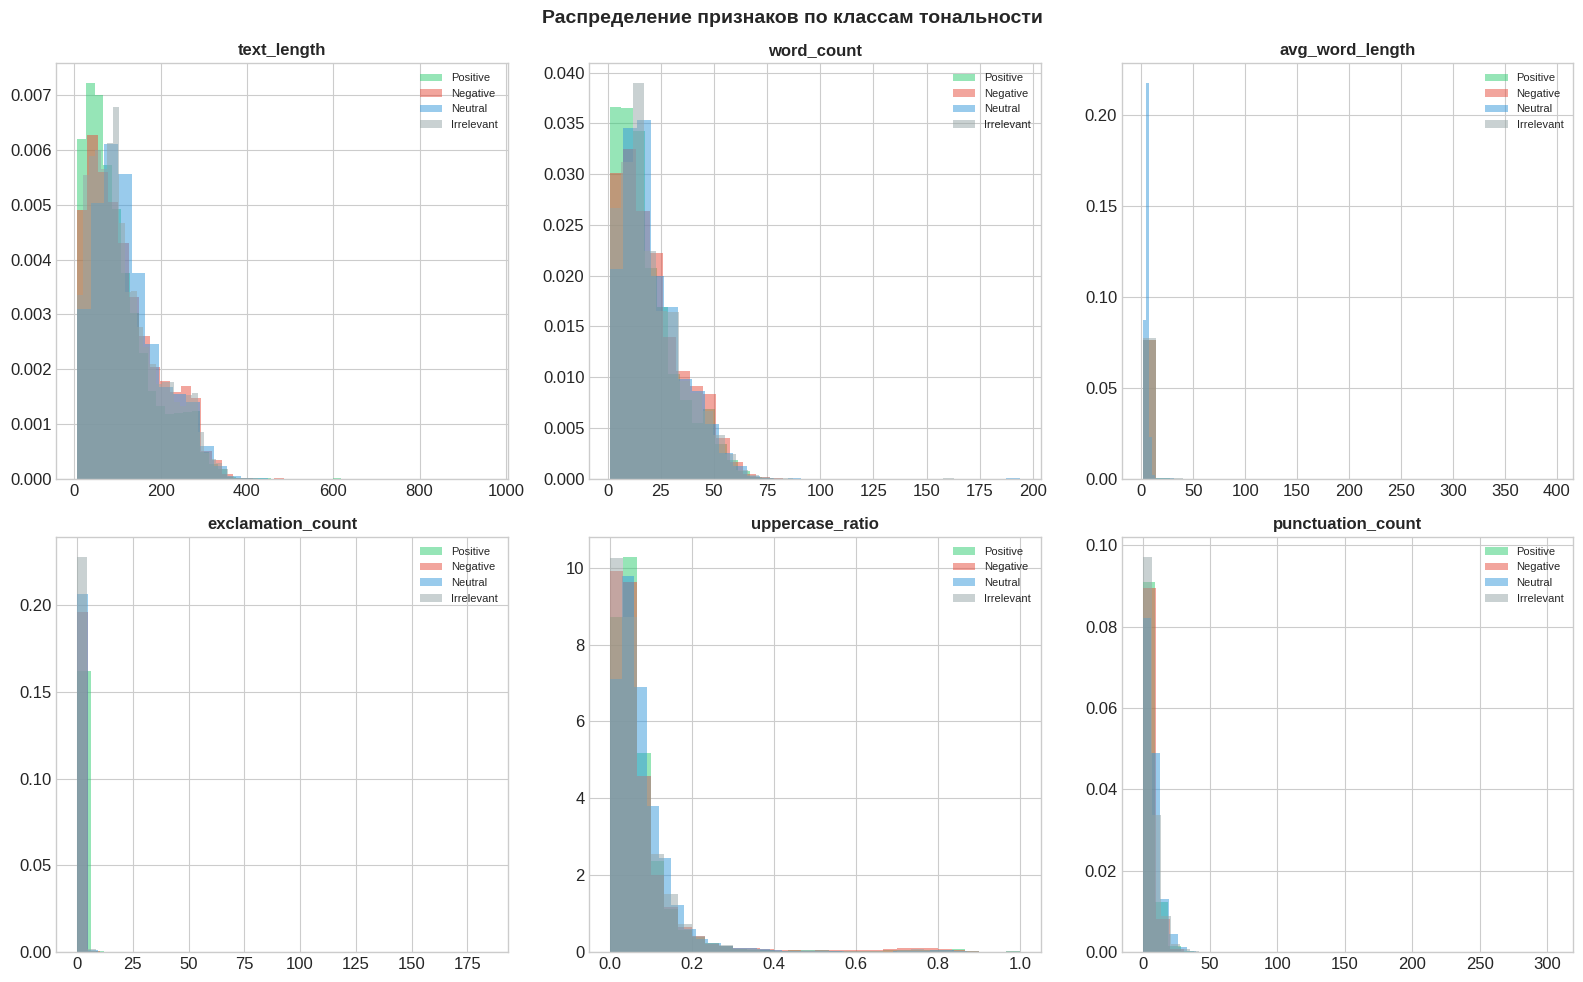

Сохранено: 04_features_by_sentiment.png


In [12]:
df['text_length'] = df['Tweet'].astype(str).str.len()
df['word_count'] = df['Tweet'].astype(str).str.split().str.len()
df['avg_word_length'] = df['Tweet'].astype(str).apply(
    lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0)
df['exclamation_count'] = df['Tweet'].astype(str).str.count('!')
df['question_count'] = df['Tweet'].astype(str).str.count(r'\?')
df['has_mention'] = df['Tweet'].astype(str).str.contains('@', regex=False).astype(int)
df['has_url'] = df['Tweet'].astype(str).str.contains(r'http|www\.', regex=True).astype(int)
df['uppercase_ratio'] = df['Tweet'].astype(str).apply(
    lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))
df['punctuation_count'] = df['Tweet'].astype(str).apply(
    lambda x: sum(1 for c in x if c in string.punctuation))
df['has_hashtag'] = df['Tweet'].astype(str).str.contains('#', regex=False).astype(int)
df['clean_word_count'] = df['clean_text'].str.split().str.len()

feature_cols = ['text_length', 'word_count', 'avg_word_length', 'exclamation_count',
                'question_count', 'has_mention', 'has_url', 'uppercase_ratio',
                'punctuation_count', 'has_hashtag', 'clean_word_count']

print(f"Создано {len(feature_cols)} дополнительных признаков:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

print(f"Статистика признаков")
print(df[feature_cols].describe().round(2))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
plot_features = ['text_length', 'word_count', 'avg_word_length',
                 'exclamation_count', 'uppercase_ratio', 'punctuation_count']

for ax, feat in zip(axes.flat, plot_features):
    for sent, color in zip(['Positive', 'Negative', 'Neutral', 'Irrelevant'],
                           ['#2ecc71', '#e74c3c', '#3498db', '#95a5a6']):
        data = df[df['Sentiment'] == sent][feat]
        ax.hist(data, bins=30, alpha=0.5, label=sent, color=color, density=True)
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Распределение признаков по классам тональности', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_features_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 04_features_by_sentiment.png")

## ЭТАП 4: ВЕКТОРИЗАЦИЯ ТЕКСТА (TF-IDF)

In [13]:
X_text = df['clean_text']
y = df['Sentiment']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Классы: {list(le.classes_)}")

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Размер обучающей выборки: {len(X_train_text)}")
print(f"Размер тестовой выборки:  {len(X_test_text)}")

tfidf = TfidfVectorizer(max_features=10000,
                        ngram_range=(1, 2),
                        min_df=3,
                        max_df=0.95,
                        sublinear_tf=True)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print(f"Размер TF-IDF матрицы (train): {X_train_tfidf.shape}")
print(f"Размер TF-IDF матрицы (test):  {X_test_tfidf.shape}")

feature_names = tfidf.get_feature_names_out()
mean_tfidf = X_train_tfidf.mean(axis=0).A1
top_idx = mean_tfidf.argsort()[-20:][::-1]
print("Топ-20 слов по среднему TF-IDF")
for i, idx in enumerate(top_idx, 1):
    print(f"  {i:2d}. {feature_names[idx]:20s} — {mean_tfidf[idx]:.4f}")

Классы: ['Irrelevant', 'Negative', 'Neutral', 'Positive']
Размер обучающей выборки: 55428
Размер тестовой выборки:  13857
Размер TF-IDF матрицы (train): (55428, 10000)
Размер TF-IDF матрицы (test):  (13857, 10000)
Топ-20 слов по среднему TF-IDF
   1. game                 — 0.0183
   2. just                 — 0.0133
   3. like                 — 0.0114
   4. love                 — 0.0111
   5. good                 — 0.0103
   6. shit                 — 0.0089
   7. play                 — 0.0087
   8. really               — 0.0083
   9. best                 — 0.0083
  10. time                 — 0.0083
  11. fuck                 — 0.0081
  12. new                  — 0.0081
  13. dont                 — 0.0070
  14. fucking              — 0.0068
  15. day                  — 0.0067
  16. great                — 0.0067
  17. people               — 0.0066
  18. got                  — 0.0065
  19. johnson              — 0.0065
  20. look                 — 0.0065


## ЭТАП 5: КЛАССИФИКАЦИЯ ТОНАЛЬНОСТИ

### Модель 1: Logistic Regression

In [14]:
results = {}
print("Модель 1: Logistic Regression")
lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)
lr_acc = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr, average='weighted')
results['Logistic Regression'] = {
    'accuracy': lr_acc,
    'f1_weighted': lr_f1,
    'predictions': y_pred_lr
}
print(f"Accuracy:    {lr_acc:.4f}")
print(f"F1 (weighted): {lr_f1:.4f}")

Модель 1: Logistic Regression
Accuracy:    0.7254
F1 (weighted): 0.7229


### Модель 2: LinearSVC

In [15]:
print("Модель 2: LinearSVC")
svc_model = LinearSVC(max_iter=2000, C=1.0, random_state=42)
svc_model.fit(X_train_tfidf, y_train)
y_pred_svc = svc_model.predict(X_test_tfidf)
svc_acc = accuracy_score(y_test, y_pred_svc)
svc_f1 = f1_score(y_test, y_pred_svc, average='weighted')
results['LinearSVC'] = {
    'accuracy': svc_acc,
    'f1_weighted': svc_f1,
    'predictions': y_pred_svc
}
print(f"Accuracy:    {svc_acc:.4f}")
print(f"F1 (weighted): {svc_f1:.4f}")

Модель 2: LinearSVC
Accuracy:    0.7772
F1 (weighted): 0.7760


### Модель 3: DistilBERT

DistilBERT - это облегчённая версия модели BERT (Bidirectional Encoder Representations from Transformers), созданная методом **дистилляции знаний** (Knowledge Distillation): большая «модель-учитель» (BERT) обучает маленькую «модель-ученика» (DistilBERT) воспроизводить своё поведение.

**Архитектура DistilBERT:**

| Компонент | Описание |
|-----------|----------|
| **Параметры** | ~66 миллионов |
| **Transformer-слои** | 6 слоёв|
| **Attention Heads** | 12 голов внимания в каждом слое |
| **Hidden Size** | 768 (размерность скрытого состояния) |
| **Vocabulary** | ~30 522 токена (WordPiece tokenizer) |

**Послойная структура:**

1. **Embedding Layer (слой эмбеддингов):**
   - Token Embeddings - преобразует каждый токен в вектор размерности 768
   - Position Embeddings - добавляет информацию о позиции токена в предложении (до 512 позиций)
   - LayerNorm + Dropout - нормализация и регуляризация

2. **6 × Transformer Encoder Blocks (основные слои):**
   Каждый блок состоит из:
   - **Multi-Head Self-Attention** (12 голов) — модель «смотрит» на все слова предложения одновременно и учится, какие слова связаны друг с другом. 12 голов позволяют улавливать разные типы связей (синтаксические, семантические и т.д.)
   - **LayerNorm** — нормализация для стабильности обучения
   - **Feed-Forward Network (FFN)** — два полносвязных слоя (768 → 3072 → 768) с активацией GELU, которые преобразуют представления
   - **Residual Connections** — остаточные связи, которые помогают градиентам «течь» через глубокую сеть

3. **Classification Head (голова классификации):**
   - Pre-classifier: Linear(768 → 768) + ReLU + Dropout — промежуточный полносвязный слой
   - Classifier: Linear(768 → num_labels) — финальный слой, выдающий логиты для каждого класса (в нашем случае 4 класса: Positive, Negative, Neutral, Irrelevant)

**Параметры обучения в нашей работе:**
- Эпохи: 3
- Batch size: 32 (train) / 64 (eval)
- Learning rate warmup: 500 шагов
- Weight decay: 0.01 (L2-регуляризация)
- Max sequence length: 128 токенов
- fp16: True (смешанная точность для ускорения на GPU)


In [17]:
train_texts = X_train_text.tolist()
test_texts = X_test_text.tolist()
train_labels = y_train.tolist()
test_labels = y_test.tolist()

print(f"Классы: {list(le.classes_)}")
print(f"Train: {len(train_texts)}, Test: {len(test_texts)}")

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)

class TweetDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = TweetDataset(train_encodings, train_labels)
test_dataset = TweetDataset(test_encodings, test_labels)

model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=len(le.classes_))

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_weighted',
    fp16=True,
)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    return {'accuracy': acc, 'f1_weighted': f1}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

print("\nПолучение предсказаний DistilBERT на тестовой выборке")
preds_output = trainer.predict(test_dataset)
y_pred_bert = preds_output.predictions.argmax(-1)

bert_acc = accuracy_score(y_test, y_pred_bert)
bert_f1 = f1_score(y_test, y_pred_bert, average='weighted')

results['DistilBERT'] = {
    'accuracy': bert_acc,
    'f1_weighted': bert_f1,
    'predictions': y_pred_bert
}

print(f"\nМодель 3: DistilBERT")
print(f"Accuracy:    {bert_acc:.4f}")
print(f"F1 (weighted): {bert_f1:.4f}")


Классы: ['Irrelevant', 'Negative', 'Neutral', 'Positive']
Train: 55428, Test: 13857


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,1.612954,1.431695,0.736162,0.733079
2,0.774377,0.832037,0.860937,0.860742
3,0.349414,0.742931,0.887277,0.887058


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Получение предсказаний DistilBERT на тестовой выборке



Модель 3: DistilBERT
Accuracy:    0.8873
F1 (weighted): 0.8871


#### Скриншоты обучения

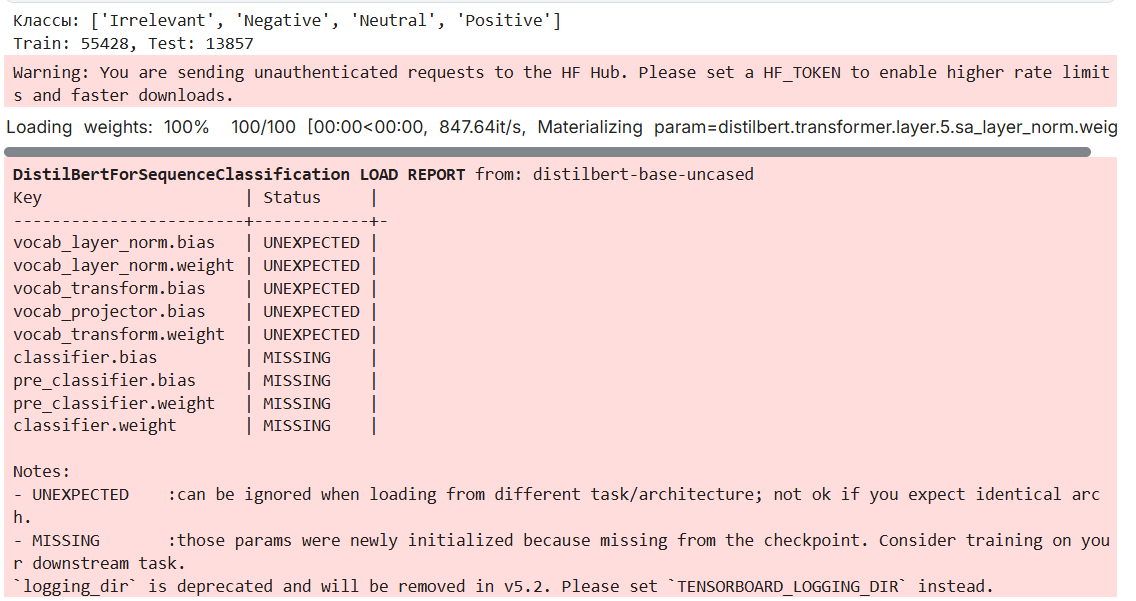

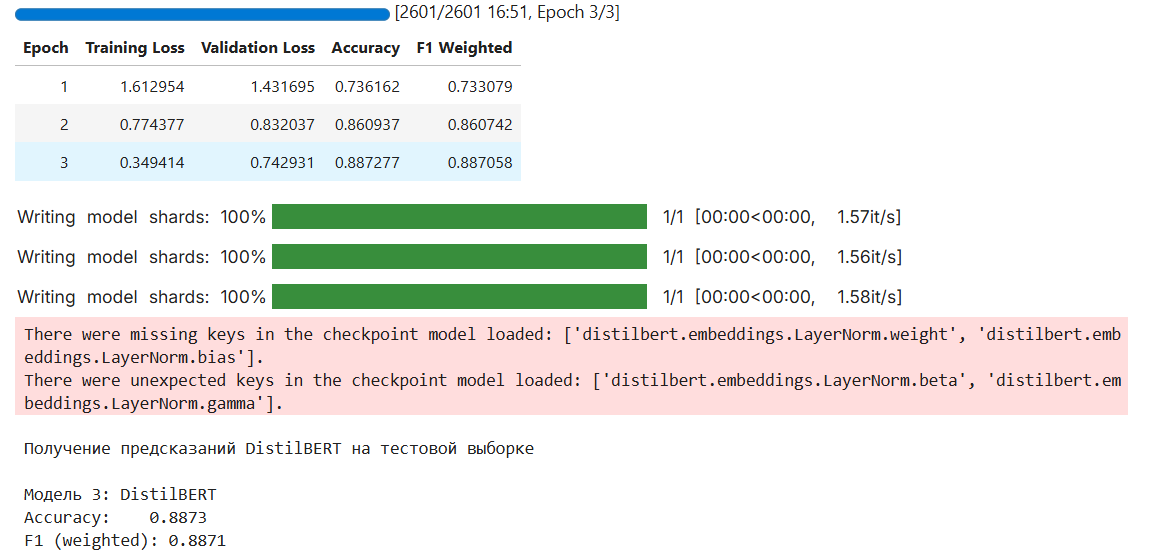

In [18]:
trainer.save_model('./distilbert_sentiment_model')
tokenizer.save_pretrained('./distilbert_sentiment_model')
print("Модель DistilBERT сохранена в ./distilbert_sentiment_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Модель DistilBERT сохранена в ./distilbert_sentiment_model


## ЭТАП 6: Технические метрики

  Logistic Regression
              precision    recall  f1-score   support

  Irrelevant       0.72      0.58      0.64      2442
    Negative       0.74      0.82      0.78      4212
     Neutral       0.72      0.68      0.70      3409
    Positive       0.72      0.75      0.73      3794

    accuracy                           0.73     13857
   macro avg       0.72      0.71      0.71     13857
weighted avg       0.72      0.73      0.72     13857

  LinearSVC
              precision    recall  f1-score   support

  Irrelevant       0.77      0.68      0.72      2442
    Negative       0.79      0.84      0.81      4212
     Neutral       0.78      0.74      0.76      3409
    Positive       0.77      0.80      0.79      3794

    accuracy                           0.78     13857
   macro avg       0.78      0.77      0.77     13857
weighted avg       0.78      0.78      0.78     13857

  DistilBERT
              precision    recall  f1-score   support

  Irrelevant       0.88     

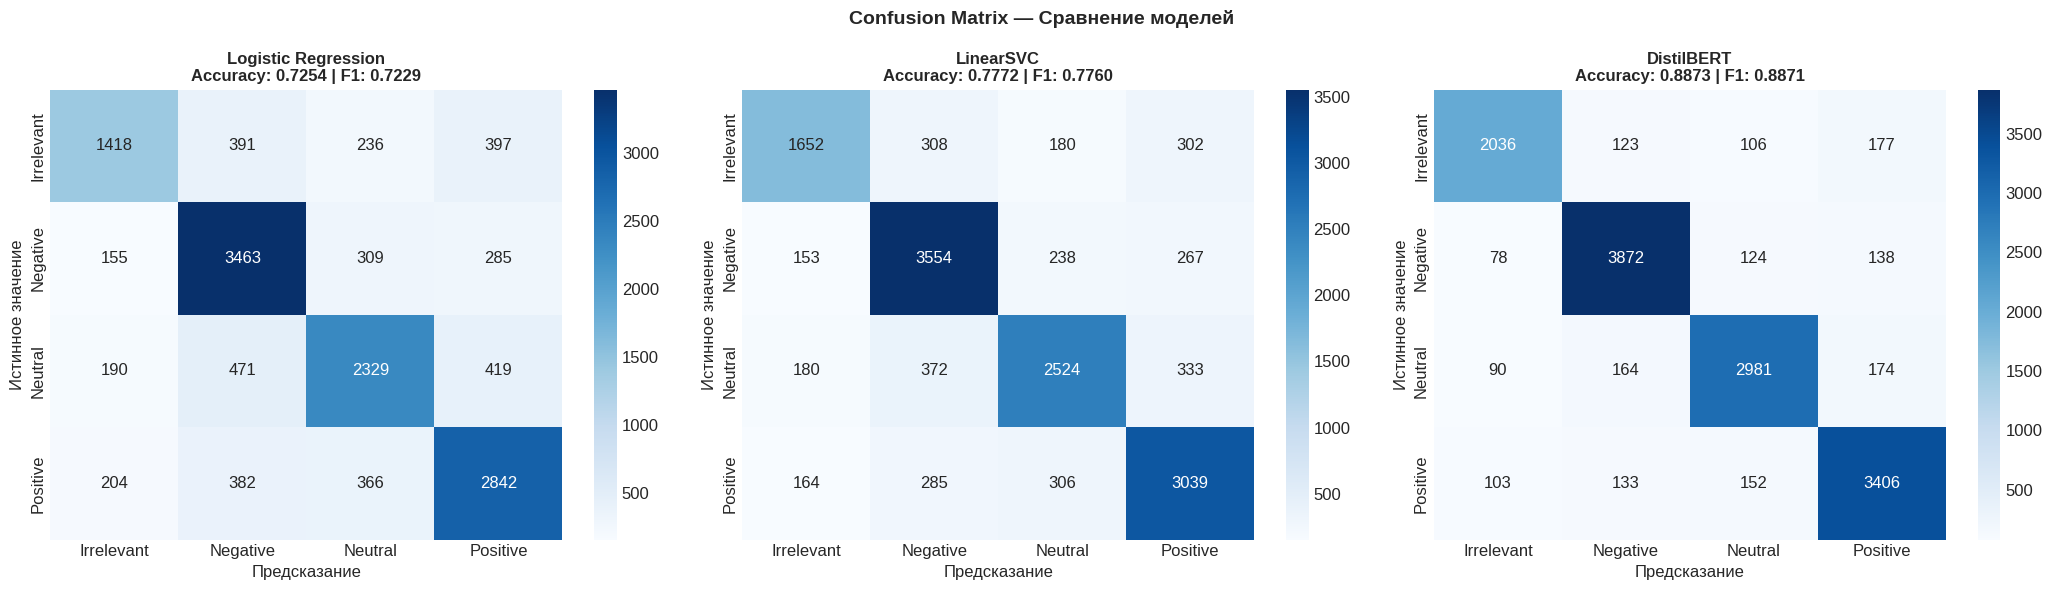

Сохранено: 05_confusion_matrices.png
 Сравнительная таблица моделей
              Model  Accuracy  F1 (weighted)  Precision (weighted)  Recall (weighted)
Logistic Regression  0.725410       0.722886              0.724856           0.725410
          LinearSVC  0.777152       0.775980              0.776831           0.777152
         DistilBERT  0.887277       0.887058              0.887236           0.887277


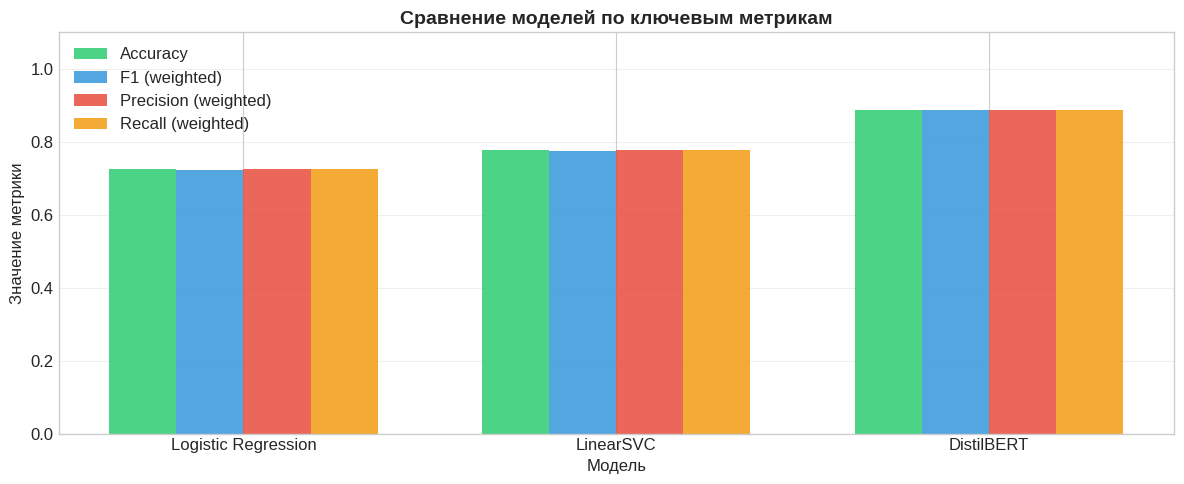

Сохранено: 06_model_comparison.png


In [19]:
class_names = list(le.classes_)

for name, res in results.items():
    print(f"  {name}")
    print(classification_report(y_test, res['predictions'], target_names=class_names))

n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 6))
if n_models == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(f'{name}\nAccuracy: {res["accuracy"]:.4f} | F1: {res["f1_weighted"]:.4f}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Предсказание')
    ax.set_ylabel('Истинное значение')

plt.suptitle('Confusion Matrix — Сравнение моделей', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 05_confusion_matrices.png")

print(" Сравнительная таблица моделей")
comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [r['accuracy'] for r in results.values()],
    'F1 (weighted)': [r['f1_weighted'] for r in results.values()],
    'Precision (weighted)': [precision_score(y_test, r['predictions'], average='weighted')
                             for r in results.values()],
    'Recall (weighted)': [recall_score(y_test, r['predictions'], average='weighted')
                          for r in results.values()],
})
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(comparison))
width = 0.18
metrics = ['Accuracy', 'F1 (weighted)', 'Precision (weighted)', 'Recall (weighted)']
colors_m = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

for i, (metric, color) in enumerate(zip(metrics, colors_m)):
    ax.bar(x + i*width, comparison[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xlabel('Модель')
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение моделей по ключевым метрикам', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison['Model'])
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('06_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 06_model_comparison.png")


## ЭТАП 7: БИЗНЕС-МЕТРИКИ БРЕНДА

### Описание бизнес-метрик и формулы расчёта


**Метрики:**

| # | Метрика | Формула | Что показывает |
|---|---------|---------|----------------|
| 1 | **Brand Sentiment Index (BSI)** | `BSI = (Positive − Negative) / Total × 100` | Общий «градус» настроения вокруг бренда. BSI > 0 - преобладает позитив, BSI < 0 - преобладает негатив |
| 2 | **Share of Voice (SOV)** | `SOV = Mentions_brand / Mentions_all × 100%` | Доля упоминаний бренда среди всех упоминаний. |
| 3 | **Volume of Mentions** | `Volume = count(mentions)` |  количество упоминаний бренда за период. |
| 4 | **Negative Sentiment Ratio** | `NSR = Negative / Total × 100%` | Доля негативных упоминаний. Высокий NSR - сигнал для команды |
| 5 | **Sentiment Polarity Distribution** | `Pos% + Neu% + Neg% + Irr% = 100%` | Полная картина распределения тональности для каждого бренда |
| 6 | **Brand Controversy Index** | `BCI = (Positive + Negative) / Total × 100` | Насколько бренд вызывает *сильные* эмоции (и позитивные, и негативные). Высокий BCI = бренд поляризует аудиторию |
| 7 | **Positive-to-Negative Ratio** | `PNR = Positive / Negative` | Сколько положительных отзывов приходится на один негативный. PNR > 1 - позитив преобладает |
| 8 | **Irrelevance Rate** | `IRR = Irrelevant / Total × 100%` | Доля шума Высокий IRR = бренд часто упоминается вне контекста |



In [20]:
ml_results = {k: v for k, v in results.items() if k != 'DistilBERT'}
best_ml_model = max(ml_results, key=lambda k: ml_results[k]['f1_weighted'])
print(f"Лучшая ML-модель (для предсказания на всех данных): {best_ml_model}")
print(f"Лучшая модель общая: {max(results, key=lambda k: results[k]['f1_weighted'])}")

X_all_tfidf = tfidf.transform(df['clean_text'])
if best_ml_model == 'Logistic Regression':
    df['predicted_sentiment'] = le.inverse_transform(lr_model.predict(X_all_tfidf))
else:
    df['predicted_sentiment'] = le.inverse_transform(svc_model.predict(X_all_tfidf))

print(f"\nПредсказания на всём датасете ({len(df)} записей) выполнены моделью {best_ml_model}")
print(df['predicted_sentiment'].value_counts())

Лучшая ML-модель (для предсказания на всех данных): LinearSVC
Лучшая модель общая: DistilBERT

Предсказания на всём датасете (69285 записей) выполнены моделью LinearSVC
predicted_sentiment
Negative      22318
Positive      19637
Neutral       16349
Irrelevant    10981
Name: count, dtype: int64


### 7.1 Brand Sentiment Index (BSI)

Brand Sentiment Index (BSI)
predicted_sentiment                Positive  Negative  Neutral  Total   BSI
Topic                                                                      
AssassinsCreed                         1346       382      163   2108  45.7
RedDeadRedemption(RDR)                  825       316      780   2081  24.5
Borderlands                             944       427      520   2142  24.1
Cyberpunk2077                           901       416      418   2081  23.3
WorldOfCraft                            724       331      968   2211  17.8
Xbox(Xseries)                           751       406      427   2129  16.2
CS-GO                                   693       377      475   2097  15.1
PlayStation5(PS5)                       805       532      435   2123  12.9
Hearthstone                             789       525      601   2146  12.3
CallOfDutyBlackopsColdWar               875       643      274   2163  10.7
Nvidia                                  725       512      7

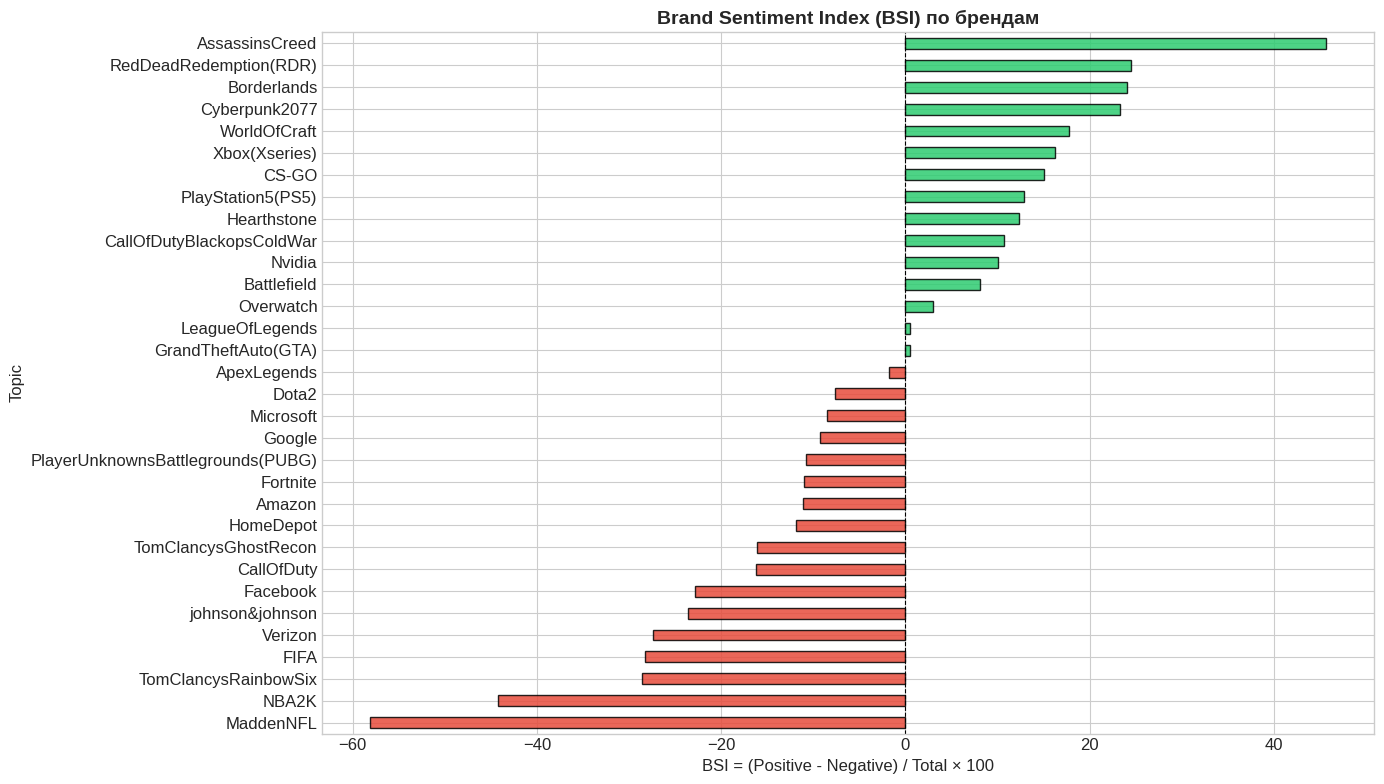

Сохранено: 07_brand_sentiment_index.png


In [21]:
# BSI = (Positive - Negative) / Total * 100
print("Brand Sentiment Index (BSI)")
brand_stats = df.groupby('Topic')['predicted_sentiment'].value_counts().unstack(fill_value=0)

for col in ['Positive', 'Negative', 'Neutral', 'Irrelevant']:
    if col not in brand_stats.columns:
        brand_stats[col] = 0

brand_stats['Total'] = brand_stats.sum(axis=1)
brand_stats['BSI'] = ((brand_stats['Positive'] - brand_stats['Negative']) / brand_stats['Total'] * 100).round(1)
brand_stats = brand_stats.sort_values('BSI', ascending=False)

print(brand_stats[['Positive', 'Negative', 'Neutral', 'Total', 'BSI']].to_string())

fig, ax = plt.subplots(figsize=(14, 8))
colors_bsi = ['#2ecc71' if v >= 0 else '#e74c3c' for v in brand_stats['BSI']]
brand_stats['BSI'].plot(kind='barh', ax=ax, color=colors_bsi, edgecolor='black', alpha=0.85)
ax.set_title('Brand Sentiment Index (BSI) по брендам', fontsize=14, fontweight='bold')
ax.set_xlabel('BSI = (Positive - Negative) / Total × 100')
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('07_brand_sentiment_index.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 07_brand_sentiment_index.png")

### 7.2 Share of Voice (SOV)

In [22]:
print("Share of Voice (SOV)")
sov = (brand_stats['Total'] / brand_stats['Total'].sum() * 100).round(2)
print(sov.sort_values(ascending=False).to_string())

Share of Voice (SOV)
Topic
CallOfDuty                           3.26
MaddenNFL                            3.25
Verizon                              3.24
Facebook                             3.21
johnson&johnson                      3.21
NBA2K                                3.21
TomClancysGhostRecon                 3.20
Microsoft                            3.20
TomClancysRainbowSix                 3.20
WorldOfCraft                         3.19
Amazon                               3.17
Battlefield                          3.16
ApexLegends                          3.15
FIFA                                 3.14
Dota2                                3.13
LeagueOfLegends                      3.13
CallOfDutyBlackopsColdWar            3.12
Google                               3.10
GrandTheftAuto(GTA)                  3.10
Hearthstone                          3.10
Borderlands                          3.09
HomeDepot                            3.09
Xbox(Xseries)                        3.07
Overwat

### 7.3 Volume of Mentions

In [23]:
print("Volume of Mentions")
print(brand_stats['Total'].sort_values(ascending=False).to_string())

Volume of Mentions
Topic
CallOfDuty                           2262
MaddenNFL                            2250
Verizon                              2248
Facebook                             2227
NBA2K                                2226
johnson&johnson                      2221
TomClancysRainbowSix                 2219
Microsoft                            2219
TomClancysGhostRecon                 2214
WorldOfCraft                         2211
Amazon                               2198
Battlefield                          2189
ApexLegends                          2185
FIFA                                 2178
Dota2                                2171
LeagueOfLegends                      2166
CallOfDutyBlackopsColdWar            2163
GrandTheftAuto(GTA)                  2149
Hearthstone                          2146
Google                               2145
HomeDepot                            2143
Borderlands                          2142
Xbox(Xseries)                        2129
Overwatch

### 7.4 Negative Sentiment Ratio

Negative Sentiment Ratio (%)
predicted_sentiment                Total  Negative  Neg_Ratio
Topic                                                        
MaddenNFL                           2250      1646       73.2
NBA2K                               2226      1412       63.4
TomClancysRainbowSix                2219      1133       51.1
FIFA                                2178      1089       50.0
Verizon                             2248      1100       48.9
TomClancysGhostRecon                2214       946       42.7
HomeDepot                           2143       906       42.3
CallOfDuty                          2262       883       39.0
johnson&johnson                     2221       773       34.8
Fortnite                            2109       718       34.0
Dota2                               2171       736       33.9
Microsoft                           2219       730       32.9
Facebook                            2227       724       32.5
PlayerUnknownsBattlegrounds(PUBG)   2038 

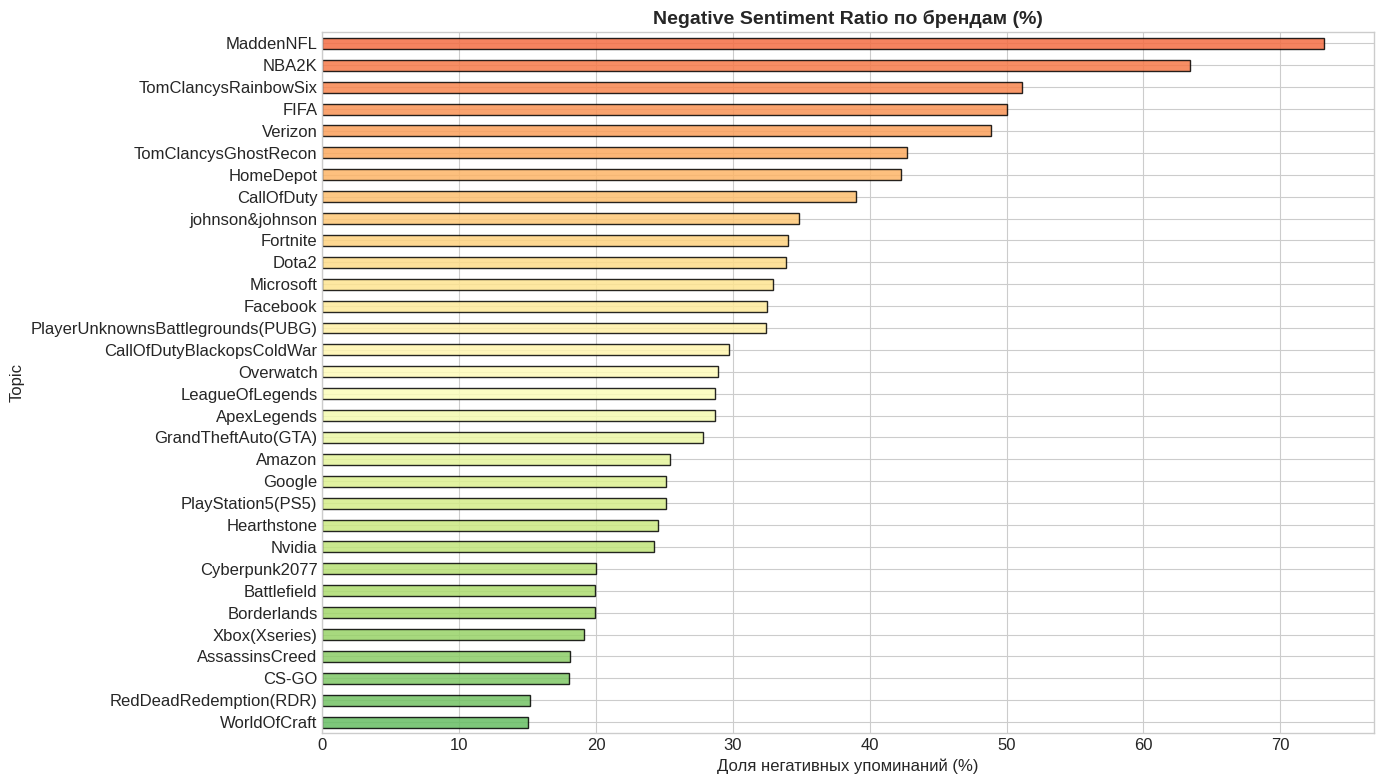

Сохранено: 08_negative_ratio.png


In [24]:
print("Negative Sentiment Ratio (%)")
brand_stats['Neg_Ratio'] = (brand_stats['Negative'] / brand_stats['Total'] * 100).round(1)
print(brand_stats[['Total', 'Negative', 'Neg_Ratio']].sort_values('Neg_Ratio', ascending=False).to_string())

fig, ax = plt.subplots(figsize=(14, 8))
neg_ratio_sorted = brand_stats['Neg_Ratio'].sort_values(ascending=True)
colors_neg = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(neg_ratio_sorted)))
neg_ratio_sorted.plot(kind='barh', ax=ax, color=colors_neg, edgecolor='black', alpha=0.85)
ax.set_title('Negative Sentiment Ratio по брендам (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Доля негативных упоминаний (%)')
plt.tight_layout()
plt.savefig('08_negative_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 08_negative_ratio.png")

### 7.5 Sentiment Polarity Distribution (для топ-10 брендов)

Sentiment Polarity Distribution (топ-10 брендов)


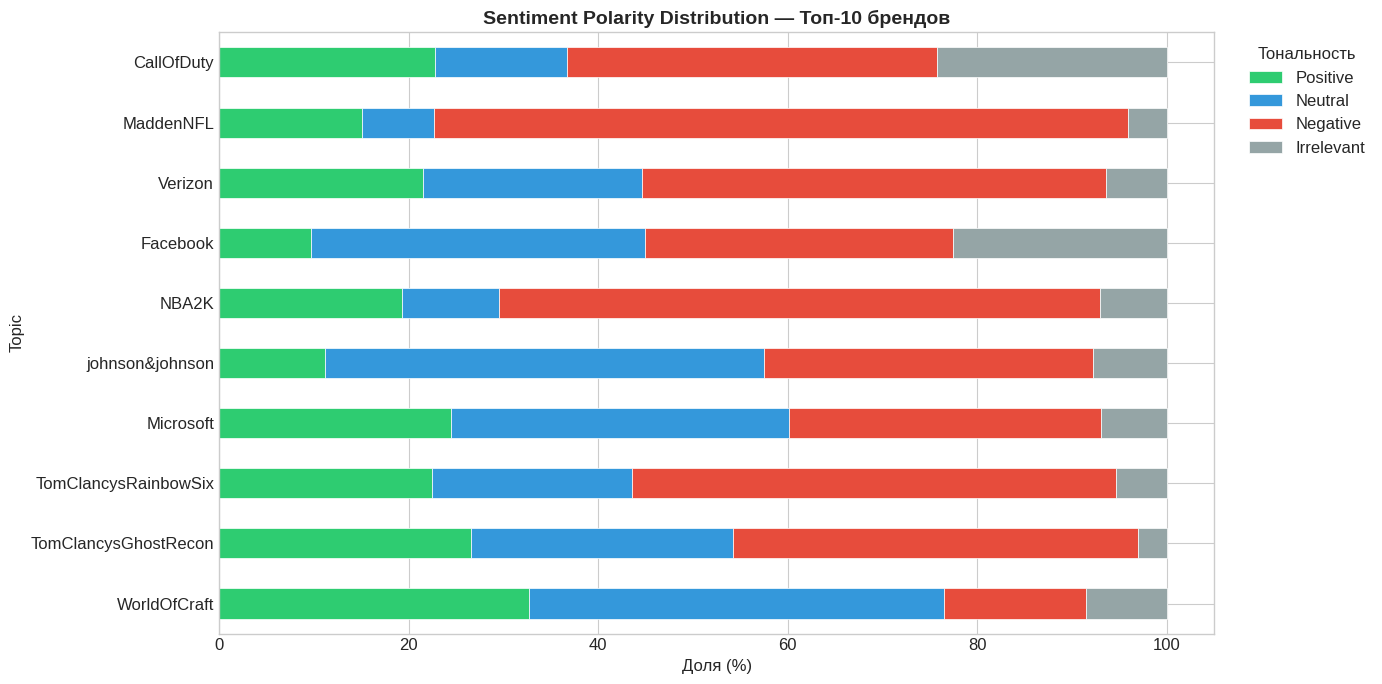

Сохранено: 09_polarity_distribution.png


In [25]:
print("Sentiment Polarity Distribution (топ-10 брендов)")
top10 = brand_stats.nlargest(10, 'Total').index

fig, ax = plt.subplots(figsize=(14, 7))
dist_data = brand_stats.loc[top10, ['Positive', 'Neutral', 'Negative', 'Irrelevant']]
dist_pct = dist_data.div(dist_data.sum(axis=1), axis=0) * 100

dist_pct[['Positive', 'Neutral', 'Negative', 'Irrelevant']].plot(
    kind='barh', stacked=True, ax=ax,
    color=['#2ecc71', '#3498db', '#e74c3c', '#95a5a6'],
    edgecolor='white', linewidth=0.5)
ax.set_title('Sentiment Polarity Distribution — Топ-10 брендов', fontsize=14, fontweight='bold')
ax.set_xlabel('Доля (%)')
ax.legend(title='Тональность', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('09_polarity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 09_polarity_distribution.png")

### 7.6 Brand Controversy Index


Brand Controversy Index (%)
predicted_sentiment                Positive  Negative  Total  Controversy
Topic                                                                    
MaddenNFL                               339      1646   2250         88.2
NBA2K                                   429      1412   2226         82.7
AssassinsCreed                         1346       382   2108         82.0
TomClancysRainbowSix                    499      1133   2219         73.5
HomeDepot                               652       906   2143         72.7
FIFA                                    473      1089   2178         71.7
Verizon                                 484      1100   2248         70.5
CallOfDutyBlackopsColdWar               875       643   2163         70.2
TomClancysGhostRecon                    589       946   2214         69.3
Borderlands                             944       427   2142         64.0
Cyberpunk2077                           901       416   2081         63.3
PlayStatio

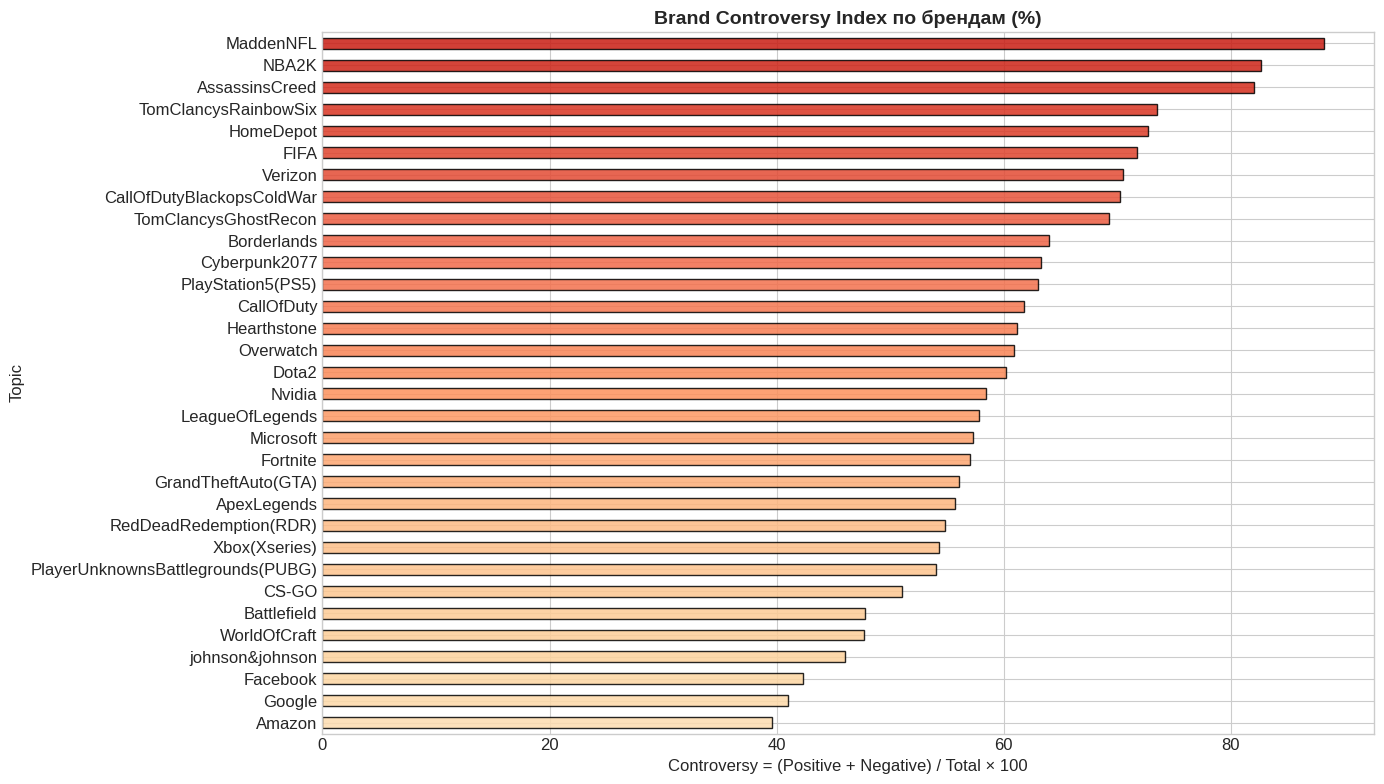

Сохранено: 10_controversy_index.png


In [26]:
# Brand Controversy Index = (Positive + Negative) / Total * 100
# Показывает, насколько бренд вызывает сильные эмоции (не нейтральные)
print("Brand Controversy Index (%)")
brand_stats['Controversy'] = ((brand_stats['Positive'] + brand_stats['Negative']) / brand_stats['Total'] * 100).round(1)
print(brand_stats[['Positive', 'Negative', 'Total', 'Controversy']].sort_values('Controversy', ascending=False).to_string())

fig, ax = plt.subplots(figsize=(14, 8))
controversy_sorted = brand_stats['Controversy'].sort_values(ascending=True)
colors_cont = plt.cm.OrRd(np.linspace(0.2, 0.8, len(controversy_sorted)))
controversy_sorted.plot(kind='barh', ax=ax, color=colors_cont, edgecolor='black', alpha=0.85)
ax.set_title('Brand Controversy Index по брендам (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Controversy = (Positive + Negative) / Total × 100')
plt.tight_layout()
plt.savefig('10_controversy_index.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 10_controversy_index.png")

### 7.7 Positive-to-Negative Ratio

Positive-to-Negative Ratio
predicted_sentiment                Positive  Negative  Pos_Neg_Ratio
Topic                                                               
AssassinsCreed                         1346       382           3.52
RedDeadRedemption(RDR)                  825       316           2.61
Borderlands                             944       427           2.21
WorldOfCraft                            724       331           2.19
Cyberpunk2077                           901       416           2.17
Xbox(Xseries)                           751       406           1.85
CS-GO                                   693       377           1.84
PlayStation5(PS5)                       805       532           1.51
Hearthstone                             789       525           1.50
Nvidia                                  725       512           1.42
Battlefield                             612       435           1.41
CallOfDutyBlackopsColdWar               875       643           1.36
Overwat

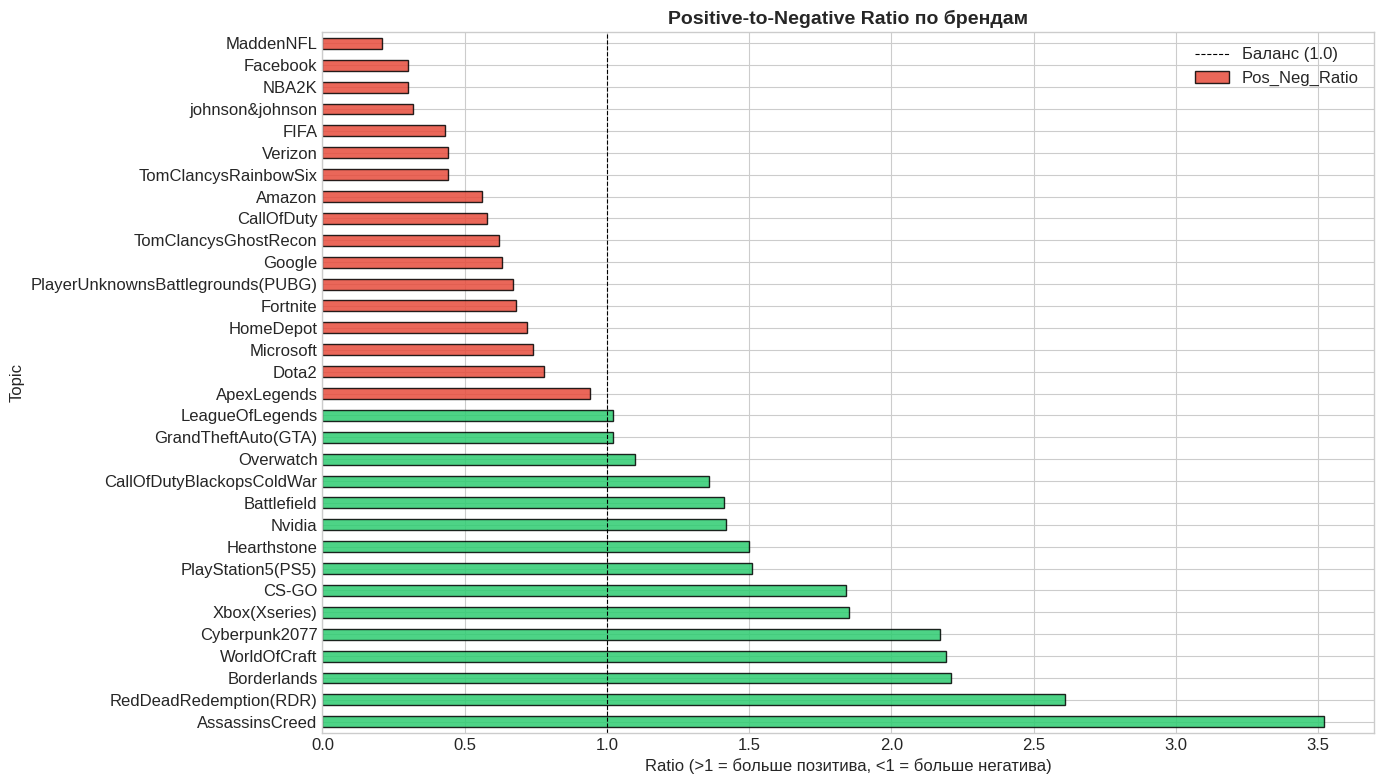

Сохранено: 11_pos_neg_ratio.png


In [27]:
# Positive-to-Negative Ratio = Positive / Negative
# Сколько положительных упоминаний приходится на одно негативное
print("Positive-to-Negative Ratio")
brand_stats['Pos_Neg_Ratio'] = (brand_stats['Positive'] / brand_stats['Negative'].replace(0, 1)).round(2)
print(brand_stats[['Positive', 'Negative', 'Pos_Neg_Ratio']].sort_values('Pos_Neg_Ratio', ascending=False).to_string())

fig, ax = plt.subplots(figsize=(14, 8))
ratio_sorted = brand_stats['Pos_Neg_Ratio'].sort_values(ascending=True)
colors_ratio = ['#2ecc71' if v >= 1 else '#e74c3c' for v in ratio_sorted]
ratio_sorted.plot(kind='barh', ax=ax, color=colors_ratio, edgecolor='black', alpha=0.85)
ax.set_title('Positive-to-Negative Ratio по брендам', fontsize=14, fontweight='bold')
ax.set_xlabel('Ratio (>1 = больше позитива, <1 = больше негатива)')
ax.axvline(x=1, color='black', linewidth=0.8, linestyle='--', label='Баланс (1.0)')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('11_pos_neg_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 11_pos_neg_ratio.png")

### 7.8 Irrelevance Rate

Irrelevance Rate (%)
predicted_sentiment                Total  Irrelevant  Irr_Rate
Topic                                                         
Battlefield                         2189         816      37.3
PlayerUnknownsBattlegrounds(PUBG)   2038         723      35.5
Fortnite                            2109         711      33.7
GrandTheftAuto(GTA)                 2149         672      31.3
Overwatch                           2128         584      27.4
CS-GO                               2097         552      26.3
Xbox(Xseries)                       2129         545      25.6
CallOfDuty                          2262         548      24.2
FIFA                                2178         495      22.7
Google                              2145         485      22.6
Facebook                            2227         503      22.6
CallOfDutyBlackopsColdWar           2163         371      17.2
Cyberpunk2077                       2081         346      16.6
PlayStation5(PS5)                 

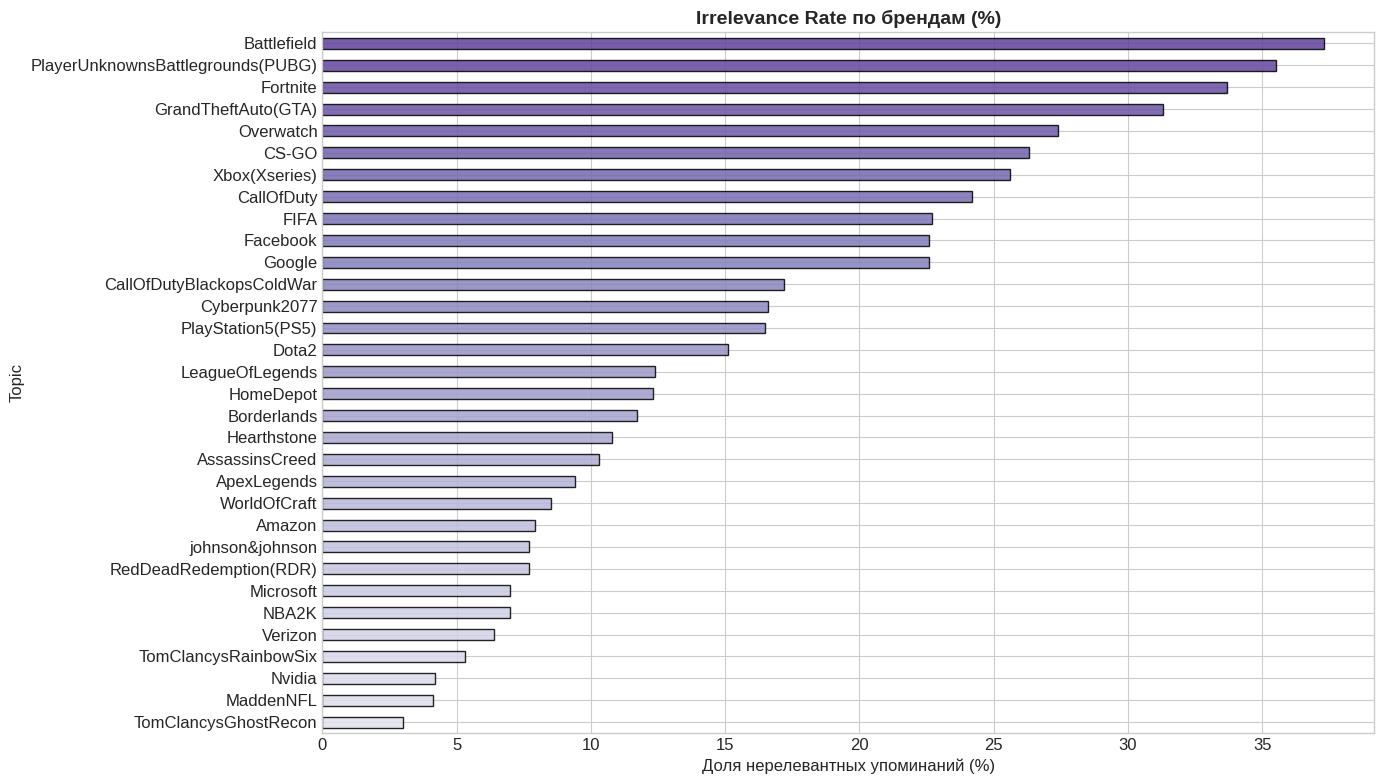

Сохранено: 12_irrelevance_rate.png


In [28]:
# Irrelevance Rate = Irrelevant / Total * 100
# Какая доля упоминаний бренда — «шум», не относящийся к теме
print("Irrelevance Rate (%)")
brand_stats['Irr_Rate'] = (brand_stats['Irrelevant'] / brand_stats['Total'] * 100).round(1)
print(brand_stats[['Total', 'Irrelevant', 'Irr_Rate']].sort_values('Irr_Rate', ascending=False).to_string())

fig, ax = plt.subplots(figsize=(14, 8))
irr_sorted = brand_stats['Irr_Rate'].sort_values(ascending=True)
colors_irr = plt.cm.Purples(np.linspace(0.2, 0.8, len(irr_sorted)))
irr_sorted.plot(kind='barh', ax=ax, color=colors_irr, edgecolor='black', alpha=0.85)
ax.set_title('Irrelevance Rate по брендам (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Доля нерелевантных упоминаний (%)')
plt.tight_layout()
plt.savefig('12_irrelevance_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 12_irrelevance_rate.png")

### 7.9 Сводная таблица бизнес-метрик

Сводная таблица бизнес-метрик (топ-10 по объёму упоминаний)
                      Упоминания   BSI  Негатив %  Controversy %  Pos/Neg Ratio  Шум %  SOV %
Topic                                                                                        
CallOfDuty                  2262 -16.2       39.0           61.8           0.58   24.2   3.26
MaddenNFL                   2250 -58.1       73.2           88.2           0.21    4.1   3.25
Verizon                     2248 -27.4       48.9           70.5           0.44    6.4   3.24
Facebook                    2227 -22.8       32.5           42.3           0.30   22.6   3.21
NBA2K                       2226 -44.2       63.4           82.7           0.30    7.0   3.21
johnson&johnson             2221 -23.6       34.8           46.0           0.32    7.7   3.21
Microsoft                   2219  -8.5       32.9           57.3           0.74    7.0   3.20
TomClancysRainbowSix        2219 -28.6       51.1           73.5           0.44    5.3   3.20


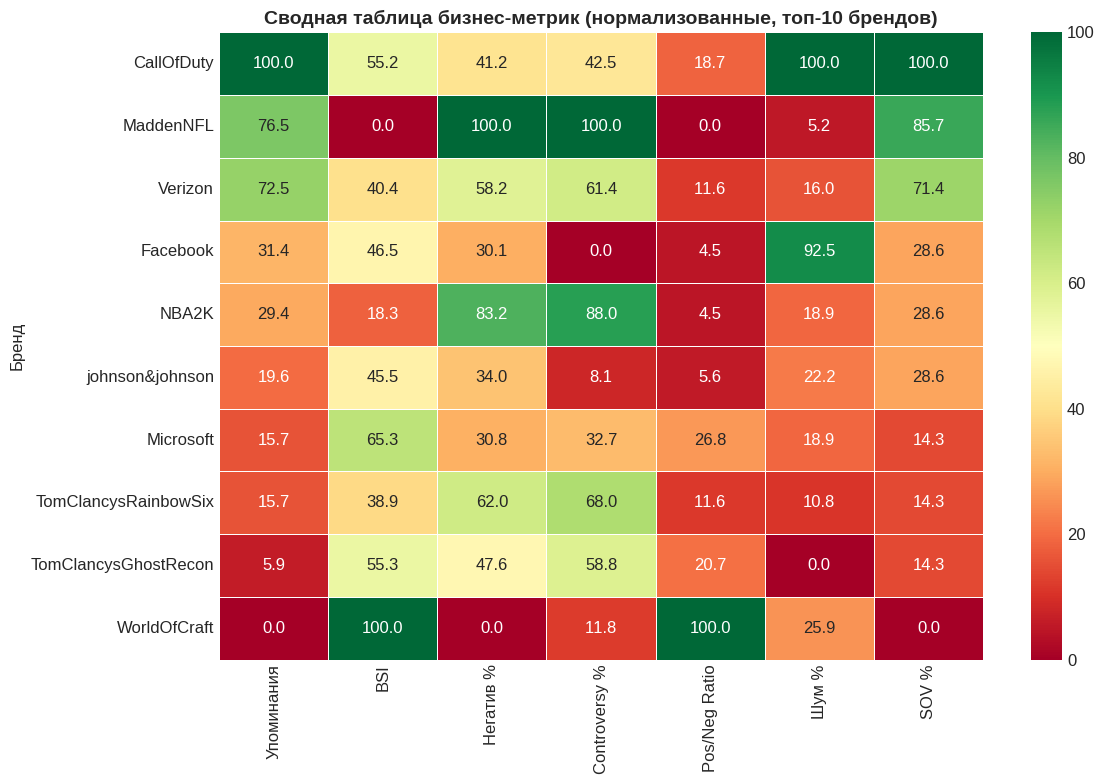

Сохранено: 13_brand_summary_heatmap.png


In [29]:
print("Сводная таблица бизнес-метрик (топ-10 по объёму упоминаний)")
top10_brands = brand_stats.nlargest(10, 'Total').index

summary_cols = ['Total', 'BSI', 'Neg_Ratio', 'Controversy', 'Pos_Neg_Ratio', 'Irr_Rate']
summary = brand_stats.loc[top10_brands, summary_cols].copy()
summary.columns = ['Упоминания', 'BSI', 'Негатив %', 'Controversy %', 'Pos/Neg Ratio', 'Шум %']

summary['SOV %'] = (summary['Упоминания'] / brand_stats['Total'].sum() * 100).round(2)

print(summary.to_string())

fig, ax = plt.subplots(figsize=(12, 8))
summary_norm = summary.copy()
for col in summary_norm.columns:
    col_min = summary_norm[col].min()
    col_max = summary_norm[col].max()
    if col_max != col_min:
        summary_norm[col] = ((summary_norm[col] - col_min) / (col_max - col_min) * 100).round(1)
    else:
        summary_norm[col] = 50.0

sns.heatmap(summary_norm, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Сводная таблица бизнес-метрик (нормализованные, топ-10 брендов)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Бренд')
plt.tight_layout()
plt.savefig('13_brand_summary_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 13_brand_summary_heatmap.png")


## ЭТАП 8: ДОПОЛНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ

### 8.1 Топ-слова для каждого класса тональности

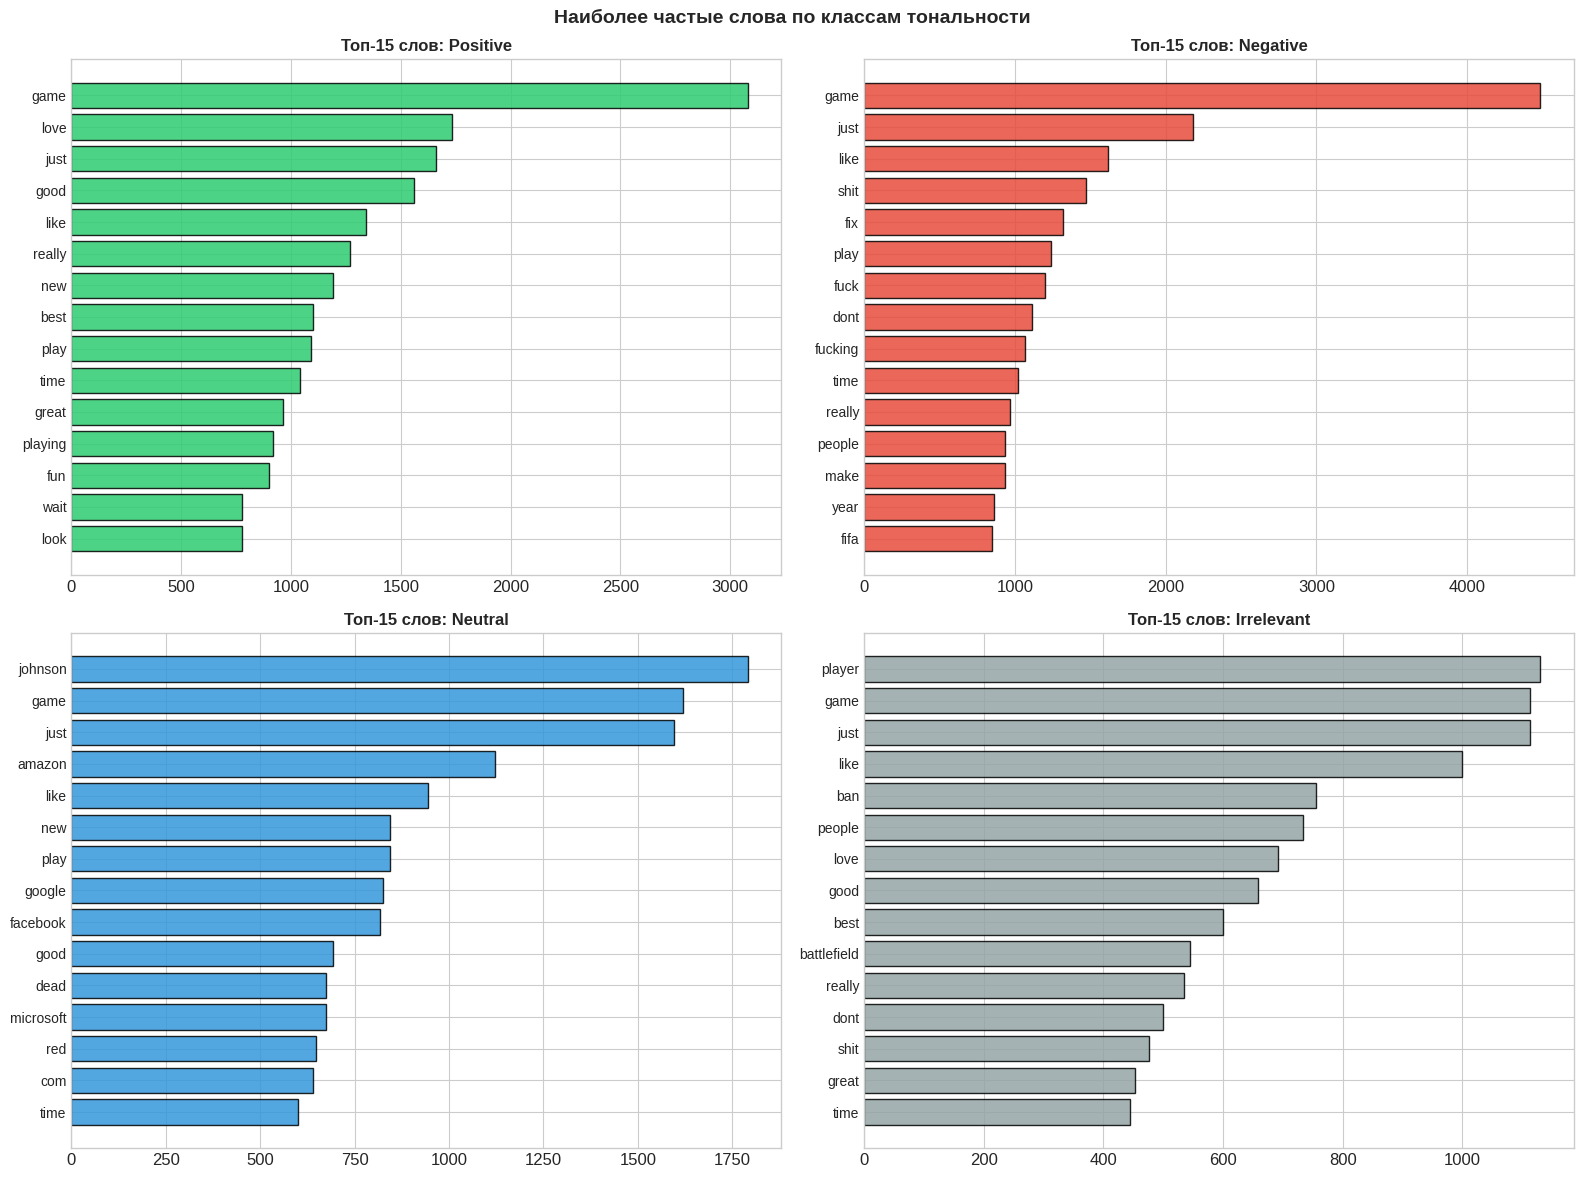

Сохранено: 10_top_words_by_sentiment.png


In [30]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sentiments = ['Positive', 'Negative', 'Neutral', 'Irrelevant']
colors_sent = ['#2ecc71', '#e74c3c', '#3498db', '#95a5a6']

for ax, sent, color in zip(axes.flat, sentiments, colors_sent):
    texts = df[df['Sentiment'] == sent]['clean_text']
    word_freq = {}
    for text in texts:
        for word in text.split():
            word_freq[word] = word_freq.get(word, 0) + 1
    top_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:15]
    words, counts = zip(*top_words) if top_words else ([], [])

    ax.barh(range(len(words)), counts, color=color, alpha=0.85, edgecolor='black')
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=10)
    ax.set_title(f'Топ-15 слов: {sent}', fontsize=12, fontweight='bold')
    ax.invert_yaxis()

plt.suptitle('Наиболее частые слова по классам тональности', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('10_top_words_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 10_top_words_by_sentiment.png")

### 8.2 Корреляция признаков

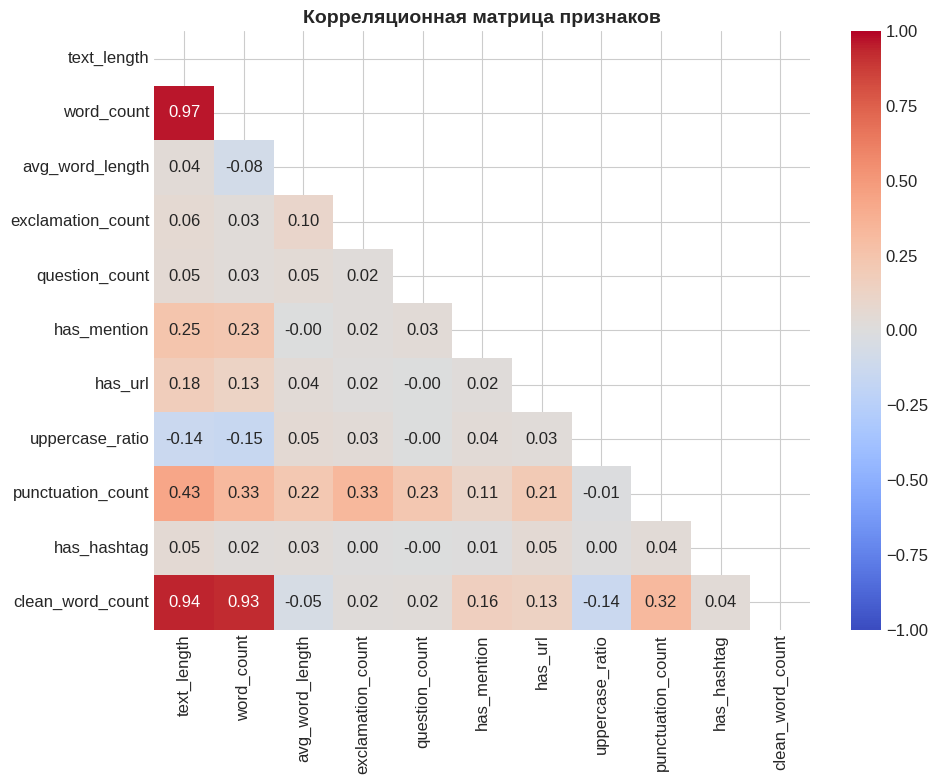

Сохранено: 11_correlation_matrix.png


In [31]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, vmin=-1, vmax=1, center=0)
ax.set_title('Корреляционная матрица признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('11_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 11_correlation_matrix.png")

### 8.3 Длина текста по классам

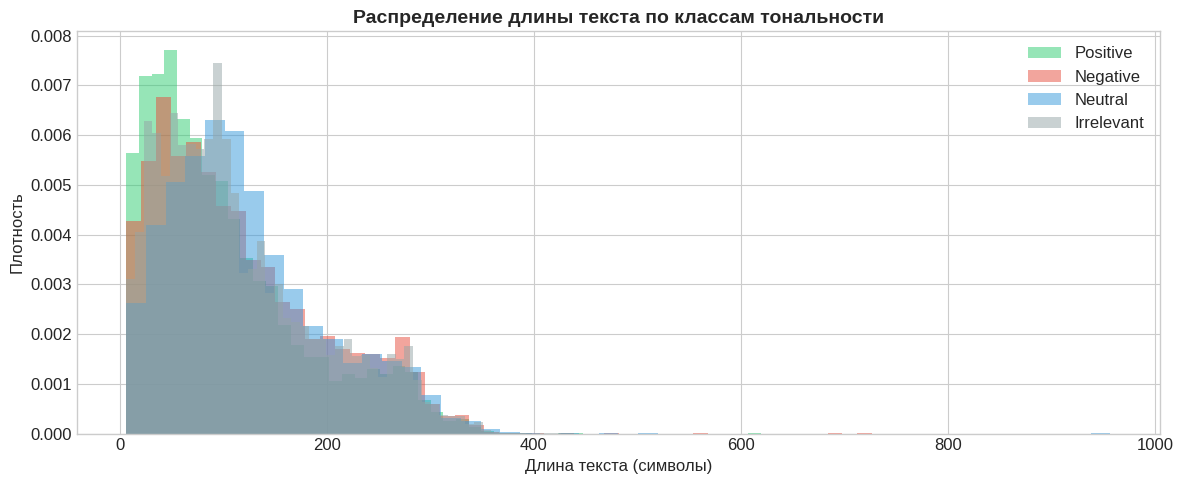

Сохранено: 12_text_length_distribution.png


In [32]:
fig, ax = plt.subplots(figsize=(12, 5))
for sent, color in zip(sentiments, colors_sent):
    data = df[df['Sentiment'] == sent]['text_length']
    ax.hist(data, bins=50, alpha=0.5, label=sent, color=color, density=True)
ax.set_title('Распределение длины текста по классам тональности', fontsize=14, fontweight='bold')
ax.set_xlabel('Длина текста (символы)')
ax.set_ylabel('Плотность')
ax.legend()
plt.tight_layout()
plt.savefig('12_text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 12_text_length_distribution.png")